In [1]:
import faiss
from pathlib import Path
from pyspark.sql import SparkSession


def get_spark(cores=8, memory="16g"):
    spark = (
        SparkSession.builder.master(f"local[{cores}]")
        .config("spark.driver.memory", memory)
        .getOrCreate()
    )
    return spark


root = Path("~/scratch/trec-tot-2025/data").expanduser()
emb_root = root / "enwiki/parquet/bge-m3-avg/v1"

spark = get_spark()
df = spark.read.parquet(emb_root.as_posix())
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/17 02:03:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- page_id: string (nullable = true)
 |-- embedding: array (nullable = true)
 |    |-- element: float (containsNull = true)



In [3]:
# let's run PCA on a small subset of the data to get some kind of scree plot
import numpy as np

sample = df.sample(fraction=0.01, seed=42).toPandas()
emb_matrix = np.array(sample["embedding"].to_list()).astype("float32")

# normalize with faiss
faiss.normalize_L2(emb_matrix)

In [4]:
emb_matrix.shape

(66311, 1024)

In [12]:
# double check the normalization
# the values look like they now
(emb_matrix**2).sum(axis=1)[:10]

array([1.        , 1.0000001 , 1.0000001 , 1.        , 1.        ,
       1.        , 1.        , 1.0000001 , 0.99999994, 0.99999994],
      dtype=float32)

In [13]:
# now run PCA via faiss and use the trace to get the scree plot
d = emb_matrix.shape[1]
n_components = d
pca_matrix = faiss.PCAMatrix(d, n_components)
pca_matrix.train(emb_matrix)

In [21]:
v = faiss.vector_float_to_array(pca_matrix.eigenvalues)
v

array([1.4182543e+03, 1.2174921e+03, 9.6950128e+02, ..., 1.1983055e-01,
       1.1026304e-01, 1.5898243e-02], shape=(1024,), dtype=float32)

102 components: 0.617 explained variance
204 components: 0.810 explained variance
307 components: 0.912 explained variance
409 components: 0.961 explained variance
512 components: 0.982 explained variance
614 components: 0.990 explained variance
716 components: 0.995 explained variance
819 components: 0.997 explained variance
921 components: 0.999 explained variance
1024 components: 1.000 explained variance
---
256 components: 0.870 explained variance
384 components: 0.953 explained variance


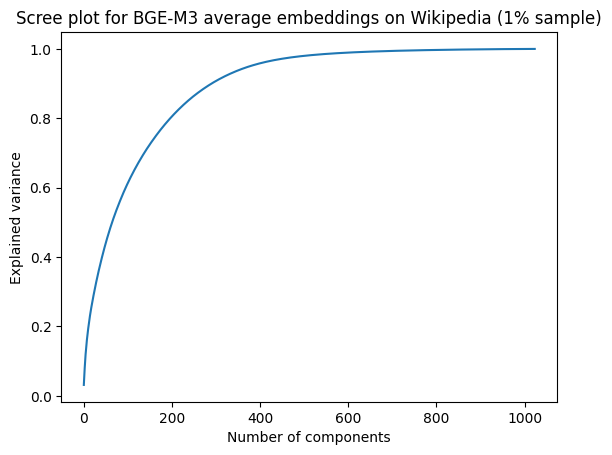

In [28]:
from matplotlib import pyplot as plt

x = v.cumsum() / v.sum()
plt.plot(x)
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("Scree plot for BGE-M3 average embeddings on Wikipedia (1% sample)")

# also print out a few values at 10% intervals
for i in range(1, 11):
    n = int(d * i / 10)
    print(f"{n} components: {x[n-1]:.3f} explained variance")
print("---")
print(f"256 components: {x[256-1]:.3f} explained variance")
print(f"384 components: {x[384-1]:.3f} explained variance")